# EDA and Preprocessing


In [ ]:
#installing neccessary packages
!pip install opendatasets -q
!pip install torchsummary -q
!pip install timm -q
!pip install torchinfo -q
!pip install tqdm -q
!pip install transformers
!pip install huggingface-hub -q

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image
import opendatasets as od

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision import transforms
import torch.nn as nn
import torchvision.models as models
from torchsummary import summary

from collections import Counter


from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split



%matplotlib inline

# Set default aesthetics for seaborn
sns.set(style="whitegrid")

In [ ]:
#downloading the dataset using kaggle api keys
od.download("https://www.kaggle.com/datasets/dilakshanchandrasena/resized-chestxray14")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: dilakshanchandrasena
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/dilakshanchandrasena/resized-chestxray14


100%|██████████| 3.95G/3.95G [00:40<00:00, 105MB/s]


In [ ]:
data_path = "/content/resized-chestxray14"
images_path = os.path.join(data_path, "chestx-ray14/content/chestxray14_resized")
df = pd.read_csv(os.path.join(data_path, "Data_Entry_2017.csv"))


In [ ]:
print("Total images:", len(df))
df.head()

Total images: 112120


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
dtypes: float64(3), int64(5), object(4)
memory usage: 10.3+ MB


In [ ]:
df["Finding Labels"] = df["Finding Labels"].apply(lambda x: x.split('|'))
df["No Finding"] = df["Finding Labels"].apply(lambda x: 1 if x == ['No Finding'] else 0)
df.drop(columns=["Unnamed: 11"], inplace=True)
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],No Finding
0,00000001_000.png,[Cardiomegaly],0,1,58,M,PA,2682,2749,0.143,0.143,0
1,00000001_001.png,"[Cardiomegaly, Emphysema]",1,1,58,M,PA,2894,2729,0.143,0.143,0
2,00000001_002.png,"[Cardiomegaly, Effusion]",2,1,58,M,PA,2500,2048,0.168,0.168,0
3,00000002_000.png,[No Finding],0,2,81,M,PA,2500,2048,0.171,0.171,1
4,00000003_000.png,[Hernia],0,3,81,F,PA,2582,2991,0.143,0.143,0


In [ ]:
#checking missing values or null values
print("\nMissing values per column:")
print(df.isnull().sum())

# Data types and quick stats
print("\nData Info:")
print(df.info())




Missing values per column:
Image Index                    0
Finding Labels                 0
Follow-up #                    0
Patient ID                     0
Patient Age                    0
Patient Gender                 0
View Position                  0
OriginalImage[Width            0
Height]                        0
OriginalImagePixelSpacing[x    0
y]                             0
No Finding                     0
dtype: int64

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender        

                    Count
No Finding          60361
Infiltration        19894
Effusion            13317
Atelectasis         11559
Nodule               6331
Mass                 5782
Pneumothorax         5302
Consolidation        4667
Pleural_Thickening   3385
Cardiomegaly         2776
Emphysema            2516
Edema                2303
Fibrosis             1686
Pneumonia            1431
Hernia                227


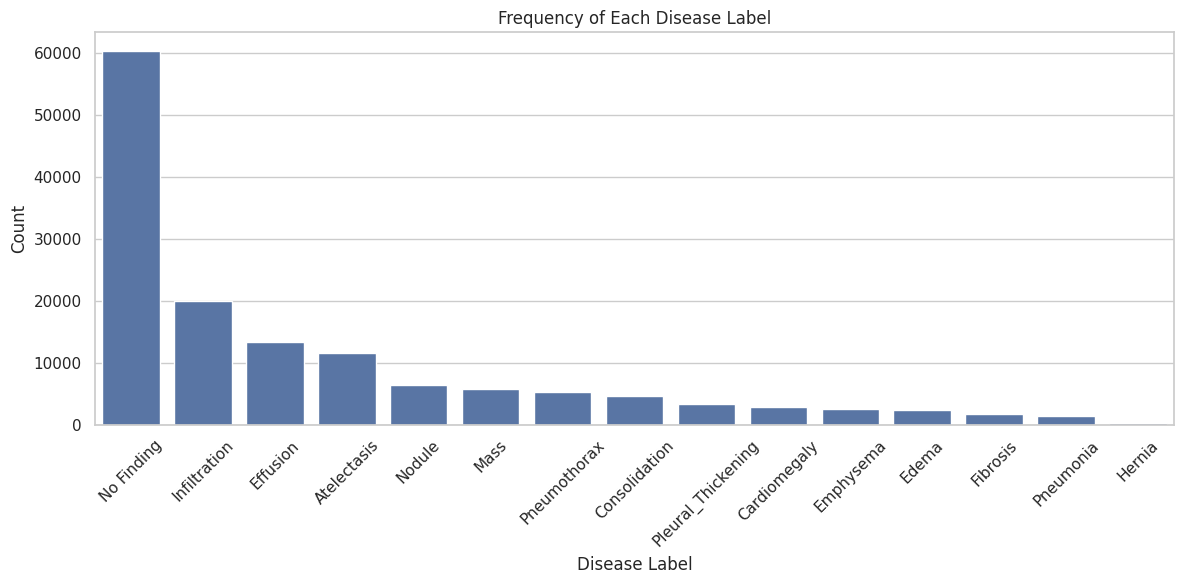

In [ ]:
all_classes = [label for sublist in df["Finding Labels"] for label in sublist]
class_counts = Counter(all_classes)
class_df = pd.DataFrame.from_dict(class_counts, orient="index", columns=["Count"])
class_df = class_df.sort_values(by='Count', ascending=False)
print(class_df)

plt.figure(figsize=(12, 6))
sns.barplot(x=class_df.index, y="Count", data=class_df)
plt.xticks(rotation=45)
plt.title("Frequency of Each Disease Label")
plt.xlabel("Disease Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

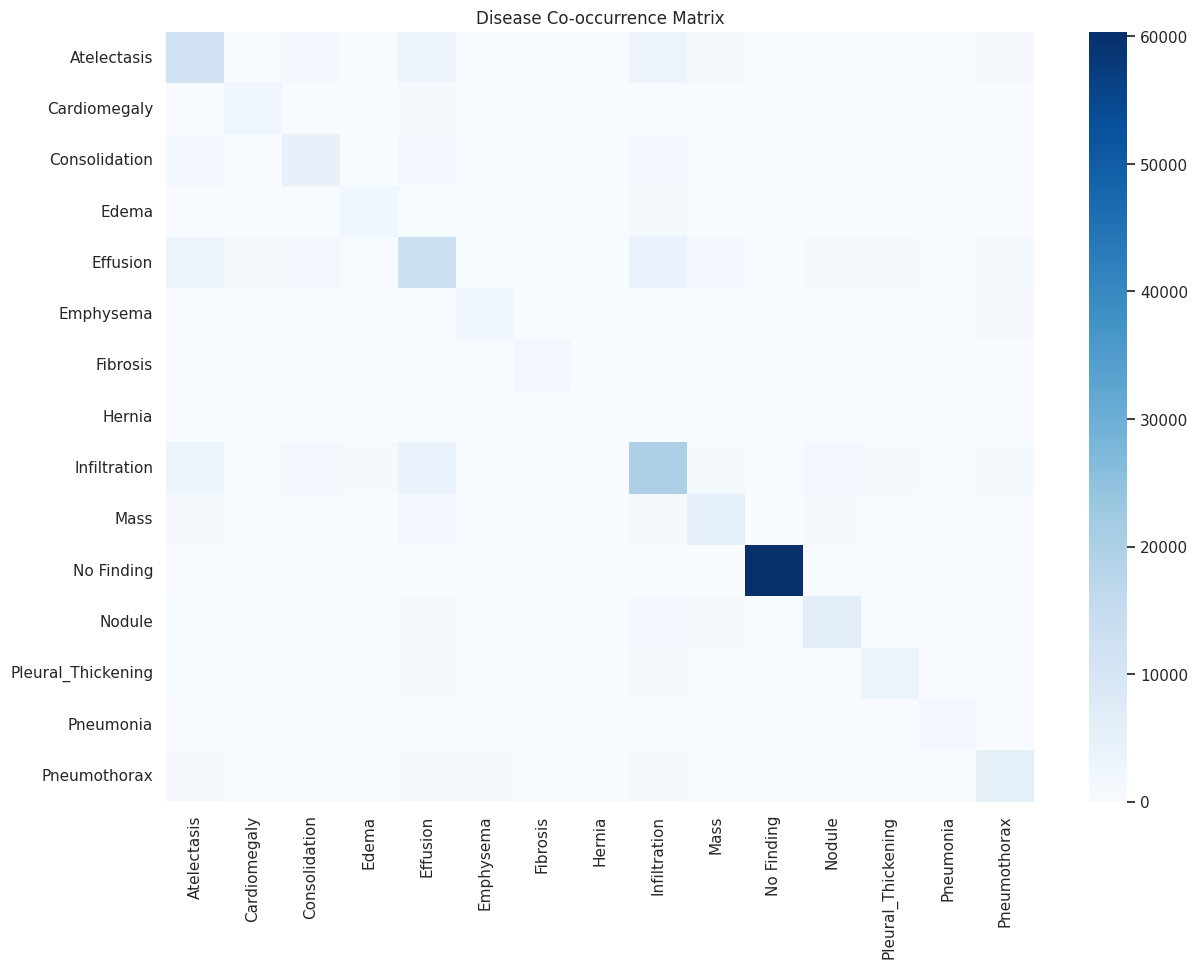

In [ ]:
mlb = MultiLabelBinarizer() #Used to convert list of labels into one-hot encoded format
label_matrix = mlb.fit_transform(df['Finding Labels'])
co_matrix = np.dot(label_matrix.T, label_matrix) #creating co-occurrence matrix to visualize disease co-occurences
co_df = pd.DataFrame(co_matrix, index=mlb.classes_, columns=mlb.classes_)

plt.figure(figsize=(14, 10))
sns.heatmap(co_df, annot=False, fmt="d", cmap="Blues")
plt.title("Disease Co-occurrence Matrix")
plt.show()

In [ ]:
no_finding_df = df[df["No Finding"] == 1]
abnormal_df   = df[df["No Finding"] != 1]
no_finding_sampled = no_finding_df.sample(n=19884, random_state=42, replace=True)
df = pd.concat([abnormal_df, no_finding_sampled])
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],No Finding
0,00000001_000.png,[Cardiomegaly],0,1,58,M,PA,2682,2749,0.143,0.143,0
1,00000001_001.png,"[Cardiomegaly, Emphysema]",1,1,58,M,PA,2894,2729,0.143,0.143,0
2,00000001_002.png,"[Cardiomegaly, Effusion]",2,1,58,M,PA,2500,2048,0.168,0.168,0
4,00000003_000.png,[Hernia],0,3,81,F,PA,2582,2991,0.143,0.143,0
5,00000003_001.png,[Hernia],1,3,74,F,PA,2500,2048,0.168,0.168,0


                    Count
Infiltration        19894
No Finding          19884
Effusion            13317
Atelectasis         11559
Nodule               6331
Mass                 5782
Pneumothorax         5302
Consolidation        4667
Pleural_Thickening   3385
Cardiomegaly         2776
Emphysema            2516
Edema                2303
Fibrosis             1686
Pneumonia            1431
Hernia                227


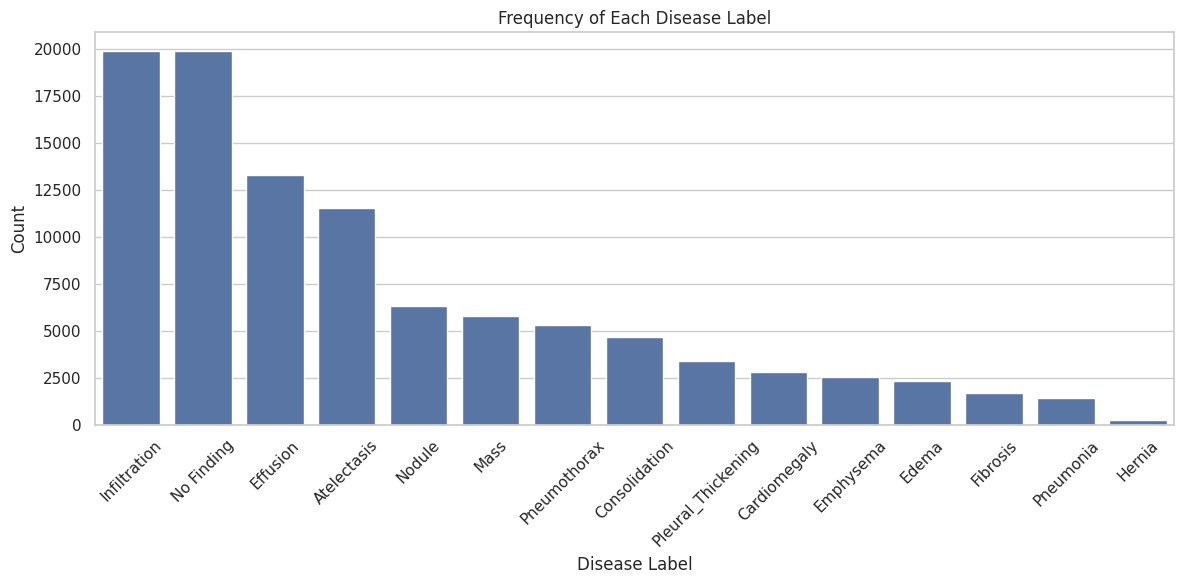

In [ ]:
all_classes = [label for sublist in df["Finding Labels"] for label in sublist]
class_counts = Counter(all_classes)
class_df = pd.DataFrame.from_dict(class_counts, orient="index", columns=["Count"])
class_df = class_df.sort_values(by='Count', ascending=False)
print(class_df)

plt.figure(figsize=(12, 6))
sns.barplot(x=class_df.index, y="Count", data=class_df)
plt.xticks(rotation=45)
plt.title("Frequency of Each Disease Label")
plt.xlabel("Disease Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

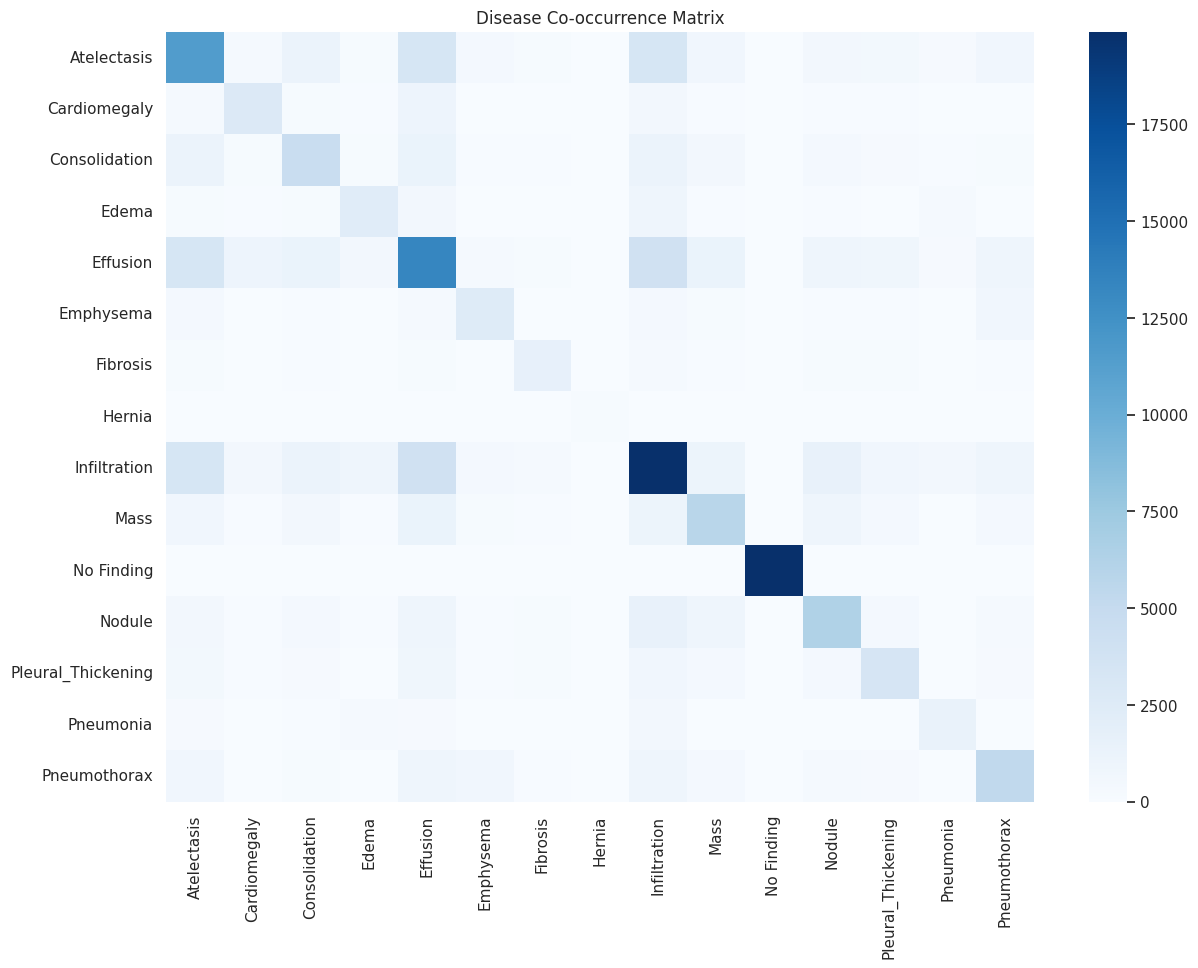

In [ ]:
label_matrix = mlb.fit_transform(df['Finding Labels'])
co_matrix = np.dot(label_matrix.T, label_matrix) #creating co-occurrence matrix to visualize disease co-occurences
co_df = pd.DataFrame(co_matrix, index=mlb.classes_, columns=mlb.classes_)

plt.figure(figsize=(14, 10))
sns.heatmap(co_df, annot=False, fmt="d", cmap="Blues")
plt.title("Disease Co-occurrence Matrix")
plt.show()

In [ ]:
label_matrix = mlb.transform(df['Finding Labels']) # Use transform, not fit_transform, as mlb is already fitted
label_cols = mlb.classes_
df_labels = pd.DataFrame(label_matrix, columns=label_cols)

df = df.reset_index(drop=True)
df_labels = df_labels.reset_index(drop=True)

# Drop the original 'No Finding' helper column from df before concatenation
df = df.drop(columns=["No Finding"])

df_combined = pd.concat([df, df_labels], axis=1)

In [ ]:
import os
from glob import glob
print(images_path)
def find_image_path(image_index):
    # Search recursively in all images_00x/images folders
    paths = glob(os.path.join(images_path, "images_*", "images", image_index))

    return paths[0] if paths else None

# Apply to your dataframe
df_combined["full_image_path"] = df_combined["Image Index"].apply(find_image_path)
print("Full paths of the images added to the DataFrame")

# Move 'full_image_path' column to the front
cols = df_combined.columns.tolist()
cols = cols[-1:] + cols[:-1]
df_combined = df_combined[cols]

df_combined.head()


/content/resized-chestxray14/chestx-ray14/content/chestxray14_resized
Full paths of the images added to the DataFrame


,full_image_path,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,/content/resized-chestxray14/chestx-ray14/cont...,00000001_000.png,[Cardiomegaly],0,1,58,M,PA,2682,2749,...,0,0,0,0,0,0,0,0,0,0
1,/content/resized-chestxray14/chestx-ray14/cont...,00000001_001.png,"[Cardiomegaly, Emphysema]",1,1,58,M,PA,2894,2729,...,1,0,0,0,0,0,0,0,0,0
2,/content/resized-chestxray14/chestx-ray14/cont...,00000001_002.png,"[Cardiomegaly, Effusion]",2,1,58,M,PA,2500,2048,...,0,0,0,0,0,0,0,0,0,0
3,/content/resized-chestxray14/chestx-ray14/cont...,00000003_000.png,[Hernia],0,3,81,F,PA,2582,2991,...,0,0,1,0,0,0,0,0,0,0
4,/content/resized-chestxray14/chestx-ray14/cont...,00000003_001.png,[Hernia],1,3,74,F,PA,2500,2048,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
df_combined = df_combined.drop(columns=["Follow-up #", "Patient Age","View Position","Patient Gender", "OriginalImage[Width","Height]", "OriginalImagePixelSpacing[x","y]"])

df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71643 entries, 0 to 71642
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   full_image_path     71643 non-null  object
 1   Image Index         71643 non-null  object
 2   Finding Labels      71643 non-null  object
 3   Patient ID          71643 non-null  int64 
 4   Atelectasis         71643 non-null  int64 
 5   Cardiomegaly        71643 non-null  int64 
 6   Consolidation       71643 non-null  int64 
 7   Edema               71643 non-null  int64 
 8   Effusion            71643 non-null  int64 
 9   Emphysema           71643 non-null  int64 
 10  Fibrosis            71643 non-null  int64 
 11  Hernia              71643 non-null  int64 
 12  Infiltration        71643 non-null  int64 
 13  Mass                71643 non-null  int64 
 14  No Finding          71643 non-null  int64 
 15  Nodule              71643 non-null  int64 
 16  Pleural_Thickening  71

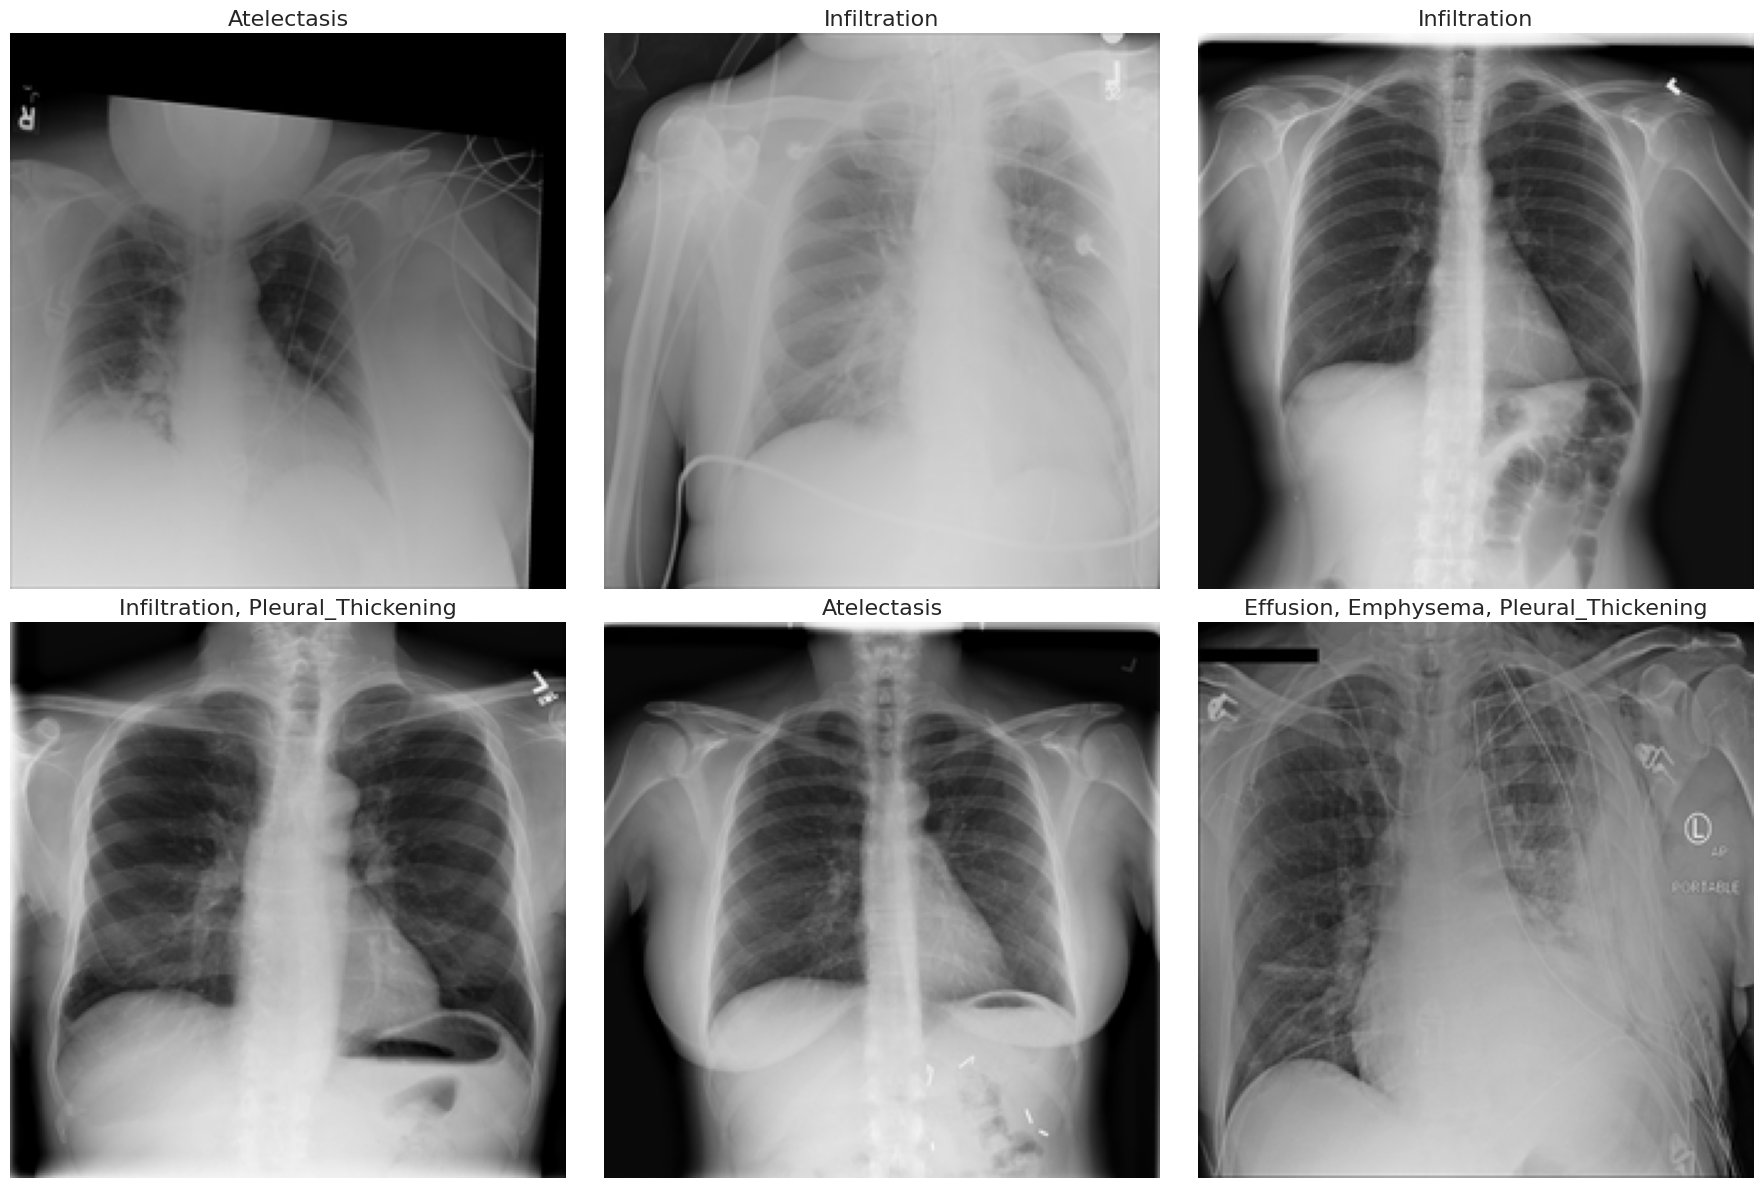

In [ ]:
from PIL import Image
import glob


def show_images(df, n_rows=2, n_cols=3):
    n_samples = n_rows * n_cols
    sample_df = df.sample(n_samples)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 6)) # Adjust figsize based on rows

    for i, (idx, row) in enumerate(sample_df.iterrows()):
        img_file = row["full_image_path"]
        label = ", ".join(row["Finding Labels"])

        image_paths = glob.glob(img_file)
        if image_paths:
            img_path = image_paths[0]
            image = Image.open(img_path).resize((224, 224))
            row_idx = i // n_cols
            col_idx = i % n_cols
            axes[row_idx, col_idx].imshow(image, cmap="gray")
            axes[row_idx, col_idx].set_title(label, fontsize=16)
            axes[row_idx, col_idx].axis('off')
        else:
            print(f"Image not found for {img_file}")

    plt.tight_layout()
    plt.show()

show_images(df_combined)

In [ ]:
#filtering patient
df_patients= df_combined["Patient ID"].unique()

train_val_patients, test_patients = train_test_split(
    df_patients, test_size=0.20, random_state=42
)

train_patients , val_patients = train_test_split(
    train_val_patients, test_size=0.125, random_state=42
)

print(f"Total patients: {len(df_patients)}")
print(f"Train patients: {len(train_patients)}")
print(f"Validation patients: {len(val_patients)}")
print(f"Test patients: {len(test_patients)}")

Total patients: 20101
Train patients: 14070
Validation patients: 2010
Test patients: 4021


In [ ]:
train_df = df_combined[df_combined["Patient ID"].isin(train_patients)].reset_index(drop=True)
val_df = df_combined[df_combined["Patient ID"].isin(val_patients)].reset_index(drop=True)
test_df = df_combined[df_combined["Patient ID"].isin(test_patients)].reset_index(drop=True)

print(f"\nDataFrame sizes:")
print(f"Train subset: {len(train_df)} images")
print(f"Validation subset: {len(val_df)} images")
print(f"Test subset: {len(test_df)} images")


DataFrame sizes:
Train subset: 50270 images
Validation subset: 7149 images
Test subset: 14224 images


In [ ]:
print("\nVerifying patient-wise split (no patient overlap)")

# Check no overlap between train and val
assert len(set(train_df["Patient ID"]) & set(val_df["Patient ID"])) == 0, "Train-Val overlap detected!"
print("No overlap between Train and Val")

# Check no overlap between train and test
assert len(set(train_df["Patient ID"]) & set(test_df["Patient ID"])) == 0, "Train-Test overlap detected!"
print("No overlap between Train and Test")

# Check no overlap between val and test
assert len(set(val_df["Patient ID"]) & set(test_df["Patient ID"])) == 0, "Val-Test overlap detected!"
print("No overlap between Val and Test")

print("\nPatient-wise split successful-no leakage!")


Verifying patient-wise split (no patient overlap)
No overlap between Train and Val
No overlap between Train and Test
No overlap between Val and Test

Patient-wise split successful-no leakage!


In [ ]:
total_images = len(df_combined)
train_count = len(train_df)
val_count = len(val_df)
test_count = len(test_df)

print("\n" + "="*60)
print("FINAL DATASET SPLIT STATISTICS")
print("="*60)
print(f"Total images in dataset:     {total_images:,}")
print(f"Training images:             {train_count:,} ({train_count/total_images*100:.1f}%)")
print(f"Validation images:           {val_count:,} ({val_count/total_images*100:.1f}%)")
print(f"Test images:                 {test_count:,} ({test_count/total_images*100:.1f}%)")
print(f"Sum (Train+Val+Test):        {train_count+val_count+test_count:,}")
print("="*60)

print("\nUnique patients:")
print(f"  Training:   {train_df['Patient ID'].nunique()} unique patients")
print(f"  Validation: {val_df['Patient ID'].nunique()} unique patients")
print(f"  Test:       {test_df['Patient ID'].nunique()} unique patients")
print("="*60)


FINAL DATASET SPLIT STATISTICS
Total images in dataset:     71,643
Training images:             50,270 (70.2%)
Validation images:           7,149 (10.0%)
Test images:                 14,224 (19.9%)
Sum (Train+Val+Test):        71,643

Unique patients:
  Training:   14070 unique patients
  Validation: 2010 unique patients
  Test:       4021 unique patients


In [ ]:
save_dir = "/content/nih-chest-x-ray-14-224x224-resized/processed-data-splits"
os.makedirs(save_dir, exist_ok=True)

train_df.to_csv(os.path.join(save_dir, "train.csv"), index=False)
val_df.to_csv(os.path.join(save_dir, "val.csv"), index=False)
test_df.to_csv(os.path.join(save_dir, "test.csv"), index=False)

print("Train, validation, and test CSVs saved to:", save_dir)

Train, validation, and test CSVs saved to: /content/nih-chest-x-ray-14-224x224-resized/processed-data-splits


In [ ]:
class ChestXrayDataset(Dataset):
    def __init__(self, df, image_dir=None, transform=None, mlb=None, label_smoothing=0.0):

        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.mlb = mlb
        self.label_smoothing = label_smoothing

        # Detect label columns
        if mlb:
            self.label_cols = mlb.classes_
        else:
            self.label_cols = [col for col in df.columns
                               if col not in ["Image Index", "Finding Labels", "No Finding", "full_path"]]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
      #print(f"Getting item {idx}")
      row = self.df.iloc[idx]

      label_vector = row[self.label_cols].values.astype("float32")
      label_vector = torch.from_numpy(label_vector) #convert np array to tensor

      # Apply label smoothing
      if self.label_smoothing > 0:
        eps = self.label_smoothing
        label_vector = label_vector * (1 - eps) + eps / len(self.label_cols)

      # Get image path from 'full_image_path'
      if 'full_image_path' in row and pd.notna(row['full_image_path']):
          img_path = row['full_image_path']
      else:
          #throw error
          raise ValueError(f"Image path not found for index {idx} in row:\n{row}")

      # Load and transform image
      image = Image.open(img_path).convert("RGB")
      if self.transform:
          image = self.transform(image)

      return image, label_vector

In [ ]:
from torchvision import transforms

# Training transform
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # Convert 1-channel to 3-channel
    transforms.Resize((224, 224)),                 # Resize to ViT/CNN input size (Dataset is already resized to 224x224)
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.01, contrast=0.01),# Augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean/std
                         std=[0.229, 0.224, 0.225])
])

# Validation/Test transform
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
train_df = pd.read_csv(save_dir + "/train.csv")
val_df = pd.read_csv(save_dir + "/val.csv")
test_df = pd.read_csv(save_dir + "/test.csv")

In [ ]:
#preporcessing data
train_dataset = ChestXrayDataset(train_df, transform=train_transform, mlb=mlb)
val_dataset = ChestXrayDataset(val_df, transform=val_transform, mlb=mlb)
test_dataset = ChestXrayDataset(test_df, transform=val_transform, mlb=mlb)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

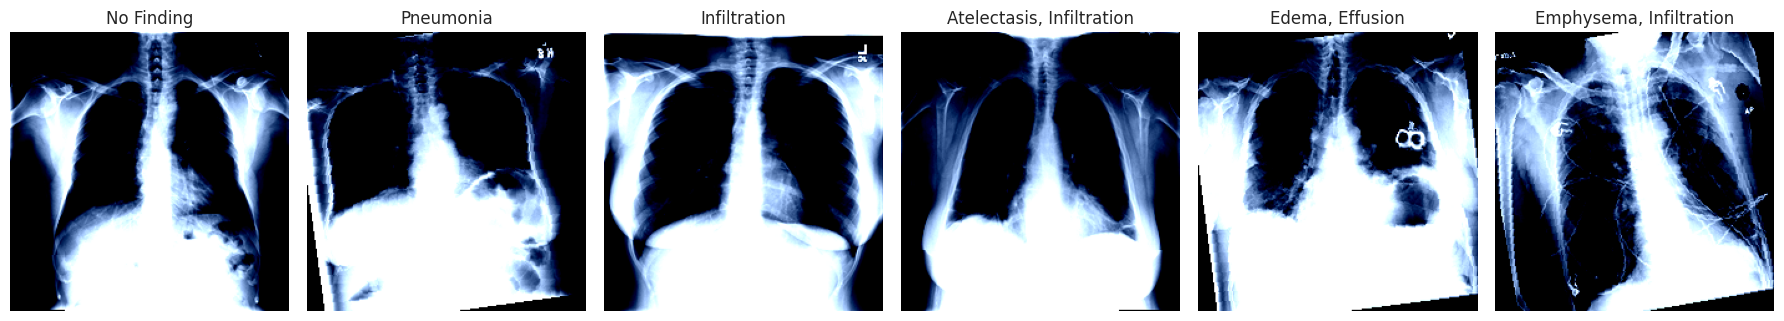

In [ ]:
def show_preprocessed_images(df,transform, n_images=6):

  """
  just for checking augmented images. Augmented images are already converted into tensors and normalised as well. Hence it might look dark.
  """
  fig, axes = plt.subplots(1, n_images, figsize=(18, 4))

  for i in range(n_images):
      row = df.sample(1).iloc[0]
      image_path = row['full_image_path']

      # Open and apply transform
      image = Image.open(image_path).convert("RGB")
      image= transform(image)


      # Convert tensor to numpy image
      np_img = image.permute(1, 2, 0).numpy()

      axes[i].imshow(np.clip(np_img, 0, 1))  # Clip for safety
      axes[i].axis('off')
      axes[i].set_title(", ".join(row["Finding Labels"]), fontsize=12)

  plt.tight_layout()
  plt.show()

# Example usage
show_preprocessed_images(df_combined, train_transform, n_images=6)

#Model Building

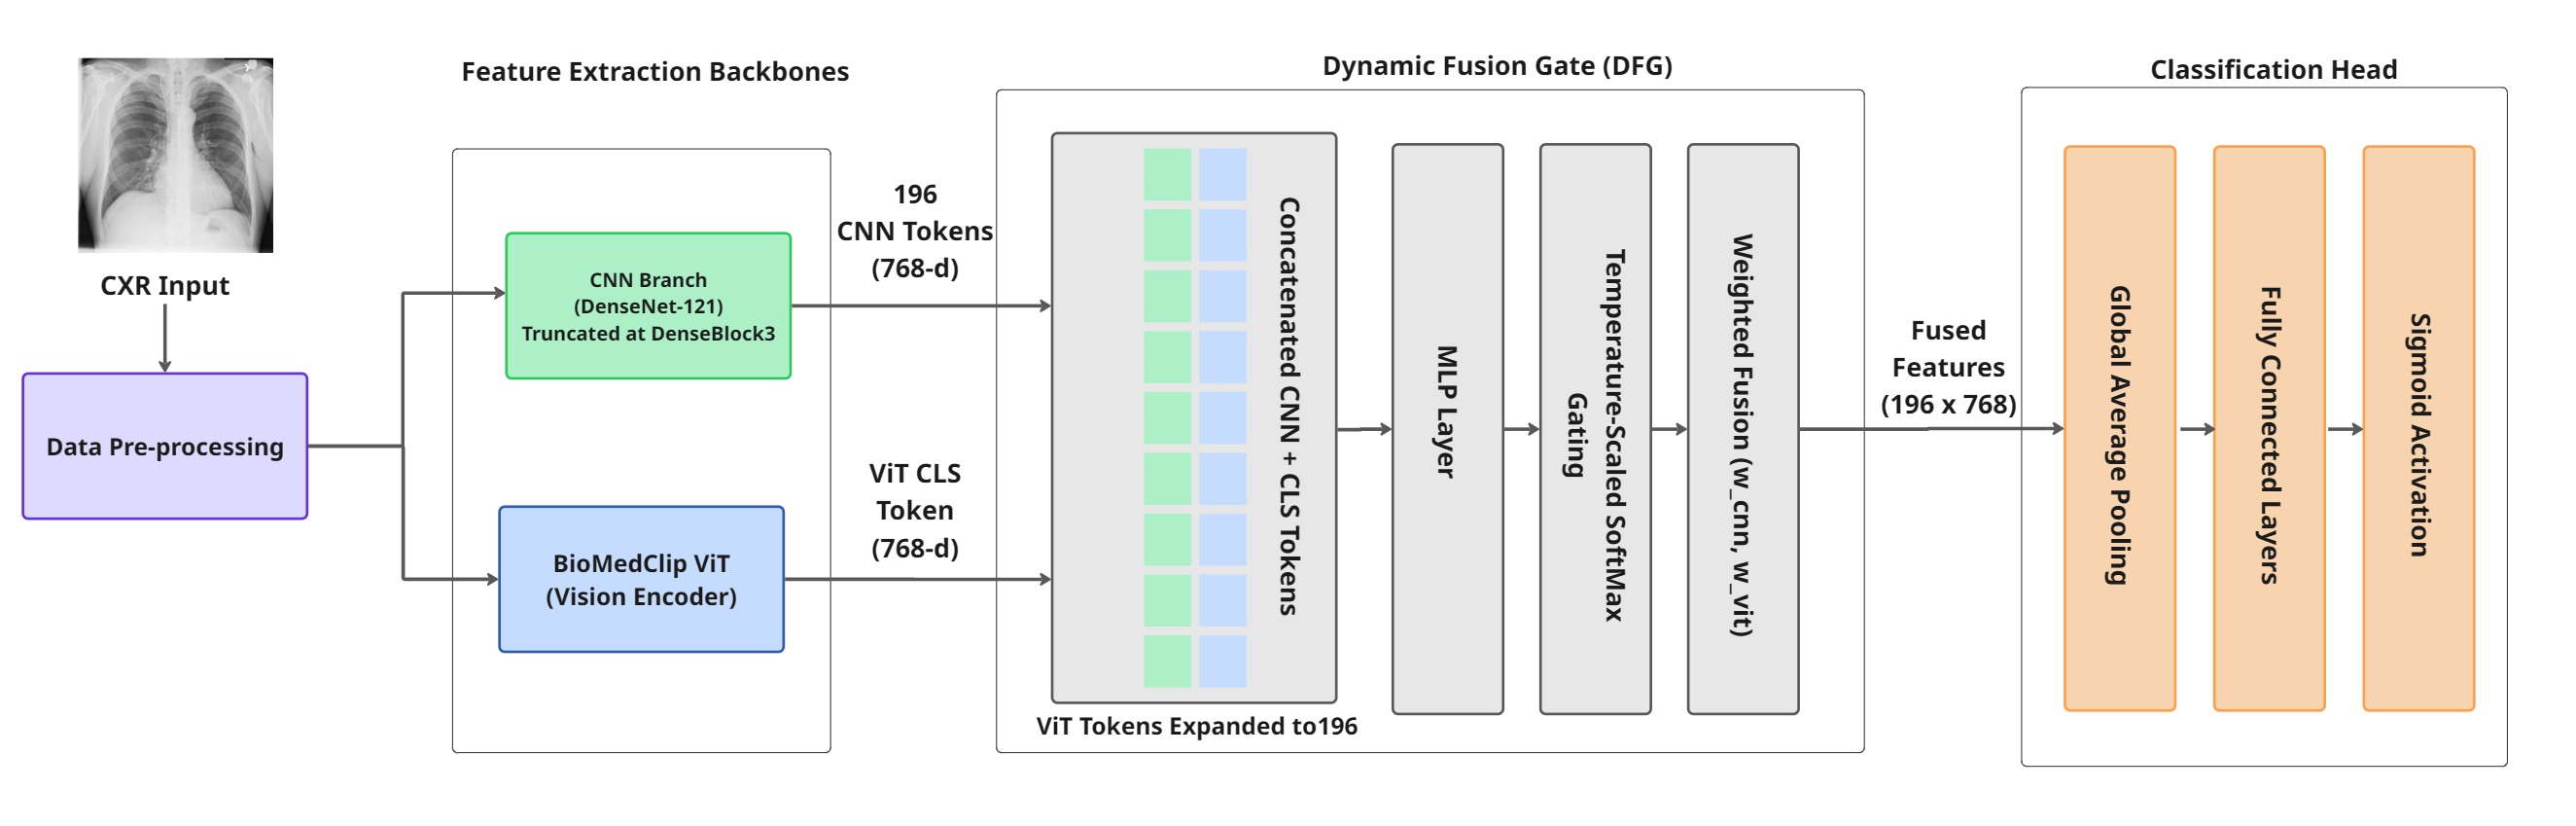

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class CNNBranch(nn.Module):
    def __init__(self, out_dim=768, pretrained=True, freeze=False):
        super(CNNBranch, self).__init__()

        #Load DenseNet-121
        densenet = models.densenet121(
            weights=models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        )

        dense_feats = list(densenet.features.children())

        # Extract up to denseblock3 (index 8)
        self.features = nn.Sequential(
            *dense_feats[:9]
            )   # includes index 8

        if freeze:
            for p in self.features.parameters():
                p.requires_grad = False

        # After denseblock3:
        # Output shape: (B, 1024, 14, 14)
        in_channels = 1024

        # Project to ViT embedding dimension
        self.proj = nn.Conv2d(in_channels, out_dim, kernel_size=1, bias=False)
        self.ln = nn.LayerNorm(out_dim)

    def forward(self, x):
        # CNN feature map: (B, 1024, 14, 14)
        feat = self.features(x)

        # Project to 768 channels
        feat = self.proj(feat)  # (B, 768, 14, 14)

        # Flatten spatial tokens 14×14 = 196 tokens
        tokens = feat.flatten(2).transpose(1, 2)  # (B, 196, 768)

        # Normalize tokens
        return self.ln(tokens)


In [ ]:
!pip install open_clip_torch transformers pillow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models


from open_clip import create_model_from_pretrained
class BiomedCLIPViTBranch(nn.Module):
    """
    BiomedCLIP ViT branch
    """
    def __init__(self, target_dim=768, freeze=True, dropout=0.1):
        super().__init__()

        print("\n" + "="*70)
        print("Loading BiomedCLIP ViT Branch (Fixed with Projection)")
        print("="*70)


        # Load BiomedCLIP model
        print("\nLoading BiomedCLIP from HuggingFace...")
        self.model, self.preprocess = create_model_from_pretrained(
            'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
        )
        self.model_loaded = "BiomedCLIP"
        print("BiomedCLIP loaded successfully!")

        # Extract vision encoder
        self.vision_model = self.model.visual
        print("Vision encoder extracted")


        if hasattr(self.vision_model, 'output_dim'):
            self.actual_dim = self.vision_model.output_dim
            print(f"    BiomedCLIP output_dim: {self.actual_dim}")
        elif hasattr(self.vision_model, 'embed_dim'):
            self.actual_dim = self.vision_model.embed_dim
            print(f"    BiomedCLIP embed_dim: {self.actual_dim}")
        else:
            # Infer from model structure
            self.actual_dim = 512  # BiomedCLIP default
            print(f"    BiomedCLIP inferred dim: {self.actual_dim}")



        print(f"\nSetting up dimension projection...")
        print(f"    Input dimension: {self.actual_dim}")
        print(f"    Target dimension: {target_dim}")

        if self.actual_dim != target_dim:
            # Create projection layer
            self.proj = nn.Linear(self.actual_dim, target_dim)
            print(f"Projection layer created ({self.actual_dim} -> {target_dim})")
            self.needs_projection = True
        else:
            # No projection needed
            self.proj = nn.Identity()
            print(f"No projection needed (dimensions match)")
            self.needs_projection = False

        self.embed_dim = target_dim  #Output dimension is always target_dim


        if freeze:
            for p in self.vision_model.parameters():
                p.requires_grad = False
            print(f"\n{self.model_loaded} backbone frozen")

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

        print(f"\n{'='*70}")
        print(f"Configuration:")
        print(f"  Model: {self.model_loaded}")
        print(f"  Input Dim: {self.actual_dim}")
        print(f"  Output Dim: {self.embed_dim}")
        print(f"  Projection: {self.needs_projection}")
        print(f"  Frozen: {freeze}")
        print(f"  Dropout: {dropout}")
        print(f"  CLIP Model Type: {type(self.vision_model)}")
        print(f"  CLIP Model: {self.vision_model}")
        print(f"{'='*70}\n")

    def forward(self, x):
            """
            x: (B, 3, H, W)
            returns: (B, embed_dim)  - projected features ready for fusion.
            """
            #extracting vison model of BiomedCLIP
            vision = self.vision_model

            # Vision models accept the image tensor and return image features.
            # Handling a few common possibilities to be robust.
            with torch.no_grad() if not any(p.requires_grad for p in vision.parameters()) else torch.enable_grad():
                # vision(x) returns a (B, D) feature tensor
                try:
                    image_features = vision(x)   # (B,D)
                except Exception:
                    # fallback- call trunk explicitly if it exists
                    if hasattr(vision, "trunk"):
                        image_features = vision.trunk(x)
                    else:
                        # trying visual.forward
                        image_features = vision.forward(x)


            if isinstance(image_features, (tuple, list)):
                image_features = image_features[0]

            # If (B, N, D) (sequence tokens), pool to get (B, D)
            if image_features.ndim == 3:
                # extracting the [cls] token
                image_features = image_features[:, 0, :]

            # Project to target dim if needed
            image_features = self.proj(image_features)   # (B, target_dim)
            image_features = self.dropout(image_features)

            return image_features  # (B, target_dim)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DynamicFusionGate(nn.Module):
    def __init__(self, embed_dim=768, hidden_dim=256, reduction="softmax",dropout=0.2, temperature=2.0):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim*2, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)
        )
        self.reduction = reduction
        self.temperature = temperature

        # This gives balanced starting point, but allows learning
        nn.init.normal_(self.mlp[-1].weight, mean=0, std=0.01)
        nn.init.constant_(self.mlp[-1].bias, 0)

    def forward(self, cnn_tokens, vit_tokens):
        # cnn_tokens: (B,196,768), vit_tokens: (B,768)
        # Expand vit_tokens to match sequence length
        B, N, D = cnn_tokens.size()
        vit_expanded = vit_tokens.unsqueeze(1).expand(B, N, D)  # (B,N,768)

        fused_input = torch.cat([cnn_tokens, vit_expanded], dim=-1)  # (B,N,1536)

        weights = self.mlp(fused_input)                              # (B,N,2)
        if self.reduction=="softmax":
            weights = torch.softmax(weights / self.temperature, dim=-1)
        else:
            weights = torch.sigmoid(weights)

        w_cnn = weights[...,0].unsqueeze(-1)  # (B,N,1)
        w_vit = weights[...,1].unsqueeze(-1)
        fused = w_cnn*cnn_tokens + w_vit*vit_expanded                  # (B,N,768)

        return fused, (w_cnn, w_vit)

In [ ]:
class MultiLabelClassifier(nn.Module):
    def __init__(self, embed_dim=768, num_classes=14, dropout=0.2):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, tokens):
        # tokens: (B,N,768)
        tokens = tokens.transpose(1,2)  # (B,768,N)
        pooled = self.pool(tokens).squeeze(-1)  # (B,768)
        out = self.dropout(pooled)
        logits = self.fc(out)  # (B,num_classes)

        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CheXDFuseNet(nn.Module):
    def __init__(self, num_classes=14, embed_dim=768, vit_model="vit_base_patch16_224"):
        super().__init__()
        self.cnn_branch = CNNBranch(out_dim=embed_dim, freeze=False)
        self.vit_branch = BiomedCLIPViTBranch(freeze=False)
        self.dfg = DynamicFusionGate(embed_dim=embed_dim, hidden_dim=256)
        self.head = MultiLabelClassifier(embed_dim=embed_dim, num_classes=num_classes)

    def forward(self, x, return_weights=True):
        f_cnn = self.cnn_branch(x)  # (B,196,768)
        f_vit = self.vit_branch(x)  # (B,768)
        fused, (w_cnn, w_vit) = self.dfg(f_cnn, f_vit)  # (B,196,768)

        logits = self.head(fused)                     # (B,14)
        if return_weights:
            return logits, (w_cnn, w_vit)
        return logits

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class EarlyStopping:
    def __init__(self, patience=7, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, value):
        score = value

        if self.best is None:
            self.best = score
            return

        improve = (score > self.best) if self.mode == "max" else (score < self.best)

        if improve:
            self.best = score
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.early_stop = True


In [ ]:
class ASLLoss(nn.Module):
    def __init__(self, gamma_pos=0, gamma_neg=4, clip=0.05, eps=1e-8):
        super().__init__()
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip
        self.eps = eps

    def forward(self, logits, targets):
        # sigmoid probabilities
        prob = torch.sigmoid(logits)
        neg_prob = 1-prob


        # Asymmetric Clipping
        if self.clip is not None and self.clip > 0:
            neg_prob = (neg_prob + self.clip).clamp(max=1)

        # Asymmetric focusing weights
        pos_weight = torch.pow(neg_prob, self.gamma_pos)
        neg_weight = torch.pow(prob, self.gamma_neg)

        # Asymmetric loss
        pos_loss = targets * pos_weight * torch.log(prob + self.eps)
        neg_loss = (1 - targets) * neg_weight * torch.log(neg_prob + self.eps)

        # combine and take mean
        loss = -(pos_loss + neg_loss)
        return loss.mean()

In [ ]:
import timm
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchinfo import summary

num_classes = len(mlb.classes_)


model = CheXDFuseNet(num_classes=num_classes).to(device)

# Loss function
criterion = ASLLoss(gamma_pos=0, gamma_neg=4, clip=0.05)


optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)


# LR scheduler
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

early_stopper = EarlyStopping(patience=4, mode="max")


print("Model, criterion, optimizer, and scheduler initialized successfully.")
summary(model, input_size=(1, 3, 224, 224))

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 142MB/s]



Loading BiomedCLIP ViT Branch (Fixed with Projection)

Loading BiomedCLIP from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

BiomedCLIP loaded successfully!
Vision encoder extracted
    BiomedCLIP inferred dim: 512

Setting up dimension projection...
    Input dimension: 512
    Target dimension: 768
Projection layer created (512 → 768)

Configuration:
  Model: BiomedCLIP
  Input Dim: 512
  Output Dim: 768
  Projection: True
  Frozen: False
  Dropout: 0.1
  CLIP Model Type: <class 'open_clip.timm_model.TimmModel'>
  CLIP Model: TimmModel(
  (trunk): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inpla

Layer (type:depth-idx)                                  Output Shape              Param #
CheXDFuseNet                                            [1, 15]                   --
├─CNNBranch: 1-1                                        [1, 196, 768]             --
│    └─Sequential: 2-1                                  [1, 1024, 14, 14]         --
│    │    └─Conv2d: 3-1                                 [1, 64, 112, 112]         9,408
│    │    └─BatchNorm2d: 3-2                            [1, 64, 112, 112]         128
│    │    └─ReLU: 3-3                                   [1, 64, 112, 112]         --
│    │    └─MaxPool2d: 3-4                              [1, 64, 56, 56]           --
│    │    └─_DenseBlock: 3-5                            [1, 256, 56, 56]          335,040
│    │    └─_Transition: 3-6                            [1, 128, 28, 28]          33,280
│    │    └─_DenseBlock: 3-7                            [1, 512, 28, 28]          919,680
│    │    └─_Transition: 3-8              

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Model Training

In [ ]:
from tqdm.auto import tqdm
import time
def train_one_epoch(model, train_loader, criterion, optimizer, epoch,
                    device, scaler, scheduler=None, log_interval=50):
    """
    Trains model for one epoch using mixed precision (AMP).
    Tracking only training loss; skip micro accuracy due to threshold bias.
    """
    model.train()
    running_loss = 0.0
    start_time = time.time()

    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch} [Train]", leave=False)

    for batch_idx, (images, targets) in pbar:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).float()

        optimizer.zero_grad()

        # Forward (autocast)
        with amp.autocast('cuda', enabled=(device.type == "cuda")):
            model_output = model(images) # model returns (logits, (w_cnn, w_vit)) by default
            logits = model_output[0]    # Extract only the logits for the loss
            loss = criterion(logits, targets)

        # Backward (scaled)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        if scheduler is not None and isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
            scheduler.step()

        batch_loss = loss.item()
        running_loss += batch_loss
        avg_loss = running_loss / (batch_idx + 1)

        lr = optimizer.param_groups[0]["lr"]

        # Update progress bar without accuracy
        pbar.set_postfix({
            "batch_loss": f"{batch_loss:.4f}",
            "avg_loss": f"{avg_loss:.4f}",
            "lr": f"{lr:.6e}"
        })
        pbar.refresh()

    epoch_loss = running_loss / len(train_loader)
    elapsed = time.time() - start_time
    print(f"Epoch [{epoch}] Train -> Loss: {epoch_loss:.4f} | Time: {elapsed:.1f}s")
    return epoch_loss

In [ ]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, hamming_loss, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
def validate(model, val_loader, criterion, epoch, device):
    model.eval()
    running_loss = 0.0
    start_time = time.time()

    all_logits = []
    all_targets = []

    pbar = tqdm(enumerate(val_loader), total=len(val_loader),
                desc=f"Epoch {epoch} [Val]", leave=False)

    for batch_idx, (images, targets) in pbar:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).float()

        with torch.no_grad(), amp.autocast('cuda', enabled=(device.type == "cuda")):
            model_output = model(images)
            logits = model_output[0]
            w_cnn, w_vit = model_output[1]
            loss = criterion(logits, targets)


            with open('fusion.txt', 'w') as f:
                f.write("--- CNN Weights (w_cnn) ---\n")
                f.write(str(w_cnn.cpu().numpy()))
                f.write("\n\n--- ViT Weights (w_vit) ---\n")
                f.write(str(w_vit.cpu().numpy()))

        batch_loss = loss.item()
        running_loss += batch_loss

        all_logits.append(logits.cpu())
        all_targets.append(targets.cpu())

        avg_loss = running_loss / (batch_idx + 1)
        pbar.set_postfix({"batch_loss": f"{batch_loss:.4f}", "avg_loss": f"{avg_loss:.4f}"})
        pbar.refresh()

    val_loss = running_loss / len(val_loader)
    all_logits = torch.cat(all_logits)
    all_targets = torch.cat(all_targets)

    y_true = all_targets.numpy()
    y_prob = torch.sigmoid(all_logits).numpy()

    # Compute per-class optimal thresholds maximizing F1
    optimal_thresholds = compute_optimal_thresholds(y_true, y_prob, step=0.01)
    print(f"\nEpoch {epoch}: Optimal thresholds per class:")
    print(np.round(optimal_thresholds, 3))

    # Apply thresholds to get binary predictions
    y_pred = apply_thresholds(y_prob, optimal_thresholds)

    # Calculate metrics
    macro_auroc = np.nanmean([
        roc_auc_score(y_true[:, i], y_prob[:, i]) if np.sum(y_true[:, i]) > 0 else np.nan
        for i in range(y_true.shape[1])
    ])
    micro_f1 = f1_score(y_true.flatten(), y_pred.flatten(), zero_division=0)
    ham_loss = hamming_loss(y_true, y_pred)

    elapsed = time.time() - start_time
    print(f"Epoch [{epoch}] Val -> Loss: {val_loss:.4f} | Macro AUROC: {macro_auroc:.4f} | Micro F1 (opt): {micro_f1:.4f} | Hamming Loss: {ham_loss:.4f} | Time: {elapsed:.1f}s")

    return val_loss, macro_auroc, micro_f1, ham_loss, optimal_thresholds


In [ ]:
checkpoint_dir = "/content/drive/MyDrive/checkpoints/CIM 02"
import os
os.makedirs(checkpoint_dir, exist_ok=True)

def save_checkpoint(model, optimizer, epoch, macro_auroc, filename):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'macro_auroc': macro_auroc
    }
    torch.save(checkpoint, filename)
    print(f"Checkpoint saved: {filename}")

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

def compute_optimal_thresholds(y_true, y_pred_prob, step=0.01):
    """
    Compute optimal threshold per class by maximizing F1.
    """
    num_classes = y_true.shape[1]
    thresholds = np.zeros(num_classes)

    for c in range(num_classes):
        best_thresh = 0.5
        best_f1 = 0
        y_true_c = y_true[:, c]
        y_pred_c = y_pred_prob[:, c]

        # Skip if no positive samples for stability
        if y_true_c.sum() == 0:
            thresholds[c] = best_thresh
            continue

        for t in np.arange(0, 1 + step, step):
            preds = (y_pred_c >= t).astype(int)
            f1 = f1_score(y_true_c, preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = t

        thresholds[c] = best_thresh

    return thresholds


def apply_thresholds(y_pred_prob, thresholds):
    """
    Apply per-class thresholds to probabilities.
    """
    y_pred_bin = np.zeros_like(y_pred_prob, dtype=int)
    for i in range(y_pred_prob.shape[1]):
        y_pred_bin[:, i] = (y_pred_prob[:, i] >= thresholds[i]).astype(int)
    return y_pred_bin


In [ ]:
from torch import amp
import torch, os
import numpy as np

def fit(model, train_loader, val_loader, device, criterion,
        optimizer, scheduler, early_stopper,
        num_epochs=25,
        save_path="checkpoints"):

    os.makedirs(save_path, exist_ok=True)

    # AMP scaler
    scaler = amp.GradScaler(enabled=(device.type == "cuda"))

    best_auc = float("-inf")

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_macro_auroc": [],
        "val_micro_f1": [],
        "val_hamming_loss": [],
        "optimal_thresholds": []
    }

    print("\n===== Starting Training =====")

    for epoch in range(1, num_epochs + 1):

        # Train one epoch
        train_loss = train_one_epoch(
            model, train_loader, criterion,
            optimizer, epoch, device, scaler, scheduler
        )

        # Validate
        val_loss, macro_auroc, micro_f1, ham_loss, optimal_thresholds = \
            validate(model, val_loader, criterion, epoch, device)

        # Logging
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_auroc"].append(macro_auroc)
        history["val_micro_f1"].append(micro_f1)
        history["val_hamming_loss"].append(ham_loss)
        history["optimal_thresholds"].append(optimal_thresholds.tolist())

        # LR scheduler step (StepLR style)
        scheduler.step()

        # Save best model based on MACRO AUC
        if macro_auroc > best_auc and not np.isnan(macro_auroc):
            best_auc = macro_auroc
            file_name = os.path.join(checkpoint_dir, f"best_model_epoch_{epoch}.pth")
            save_checkpoint(model, optimizer, epoch, macro_auroc, file_name)
            print(f"Saved best model (epoch {epoch}) with macro auc {macro_auroc:.4f}")

        # Early Stopping
        early_stopper(macro_auroc)
        if early_stopper.early_stop:
            return history
            print("\nEarly stopping triggered.\n")
            break

    print("\n===== Training Complete! =====\n")
    return history


In [ ]:
history = fit(
    model,
    train_loader,
    val_loader,
    device,
    criterion,
    optimizer,
    scheduler,
    early_stopper,
    num_epochs=25,
    save_path=checkpoint_dir
)



===== Starting Training =====


Epoch 1 [Train]:   0%|          | 0/1571 [00:00<?, ?it/s]

Epoch [1] Train -> Loss: 0.0825 | Time: 733.8s


Epoch 1 [Val]:   0%|          | 0/224 [00:00<?, ?it/s]


Epoch 1: Optimal thresholds per class:
[0.45 0.45 0.44 0.51 0.64 0.54 0.41 0.28 0.49 0.53 0.56 0.46 0.48 0.41
 0.53]
Epoch [1] Val -> Loss: 0.0802 | Macro AUROC: 0.7773 | Micro F1 (opt): 0.4344 | Hamming Loss: 0.1462 | Time: 40.9s
Checkpoint saved: /content/drive/MyDrive/checkpoints/CIM 02/best_model_epoch_1.pth
Saved best model (epoch 1) with macro auc 0.7773


...


Epoch 9: Optimal thresholds per class:
[0.56 0.63 0.46 0.5  0.65 0.42 0.43 0.55 0.49 0.6  0.52 0.54 0.48 0.46
 0.58]
Epoch [9] Val -> Loss: 0.0849 | Macro AUROC: 0.7964 | Micro F1 (opt): 0.4531 | Hamming Loss: 0.1260 | Time: 40.3s


Epoch 10 [Train]:   0%|          | 0/1571 [00:00<?, ?it/s]

Epoch [10] Train -> Loss: 0.0614 | Time: 731.0s


Epoch 10 [Val]:   0%|          | 0/224 [00:00<?, ?it/s]


Epoch 10: Optimal thresholds per class:
[0.54 0.59 0.47 0.61 0.56 0.51 0.51 0.67 0.5  0.55 0.5  0.48 0.52 0.45
 0.52]
Epoch [10] Val -> Loss: 0.0880 | Macro AUROC: 0.7930 | Micro F1 (opt): 0.4549 | Hamming Loss: 0.1287 | Time: 39.9s


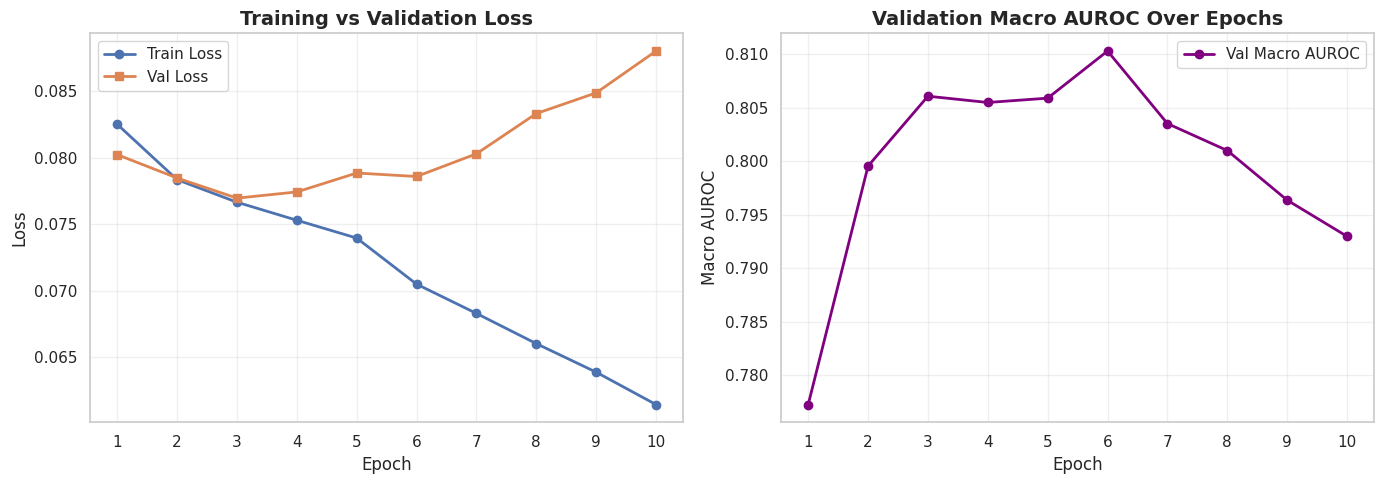

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_curves(history):

    # Epoch indexing
    num_epochs = len(history["train_loss"])
    epochs = np.arange(1, num_epochs + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Loss curves
    ax1 = axes[0]
    ax1.plot(epochs, history["train_loss"], label="Train Loss", marker='o', linewidth=2, markersize=6)
    ax1.plot(epochs, history["val_loss"], label="Val Loss", marker='s', linewidth=2, markersize=6)

    ax1.set_title("Training vs Validation Loss", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Loss", fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(epochs)

    # Plot 2: Macro AUROC curve
    ax2 = axes[1]
    ax2.plot(epochs, history["val_macro_auroc"], label="Val Macro AUROC", color='purple',
             marker='o', linewidth=2, markersize=6)

    ax2.set_title("Validation Macro AUROC Over Epochs", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Epoch", fontsize=12)
    ax2.set_ylabel("Macro AUROC", fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(epochs)

    plt.tight_layout()
    plt.show()


plot_training_curves(history)

In [ ]:
torch.save(model, (checkpoint_dir+"/final"))

#Model Testing

In [ ]:
# Load (in a new session/process)
device2 = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Loading bets model")
model_best =CheXDFuseNet(num_classes=num_classes).to(device2)      # recreate the architecture
checkpoint = torch.load("/content/drive/MyDrive/checkpoints/CIM 02/best_model_epoch_6.pth", map_location="cpu", weights_only=False)
model_best.load_state_dict(checkpoint['model_state_dict'])
model_best.eval()                      # important for inference

Loading bets model



Loading BiomedCLIP ViT Branch (Fixed with Projection)

Loading BiomedCLIP from HuggingFace...
BiomedCLIP loaded successfully!
Vision encoder extracted
    BiomedCLIP inferred dim: 512

Setting up dimension projection...
    Input dimension: 512
    Target dimension: 768
Projection layer created (512 → 768)

Configuration:
  Model: BiomedCLIP
  Input Dim: 512
  Output Dim: 768
  Projection: True
  Frozen: False
  Dropout: 0.1
  CLIP Model Type: <class 'open_clip.timm_model.TimmModel'>
  CLIP Model: TimmModel(
  (trunk): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          

CheXDFuseNet(
  (cnn_branch): CNNBranch(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, tr

In [ ]:

def plot_roc_curves(y_true, y_prob, class_names):
    n_classes = y_true.shape[1]
    plt.figure(figsize=(16, 12))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
    # Plot micro-average ROC
    fpr_micro, tpr_micro, _ = roc_curve(y_true.ravel(), y_prob.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, color='black', lw=3, linestyle='--',
             label=f'Micro-average ROC curve (AUC = {roc_auc_micro:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves per Class and Micro-average')
    plt.legend(loc="lower right", fontsize='small')
    plt.grid(True)
    plt.show()


In [ ]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, hamming_loss, classification_report, roc_curve, auc, multilabel_confusion_matrix
import matplotlib.pyplot as plt


def evaluate_test_set(model, test_loader, device, class_names, val_optimal_thresholds=None):
    model.eval()
    all_logits = []
    all_targets = []

    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device)
            targets = targets.to(device)
            model_output = model(images)
            logits = model_output[0]
            w_cnn, w_vit = model_output[1]
            all_logits.append(logits.cpu())
            all_targets.append(targets.cpu())

    y_true = torch.cat(all_targets).numpy()
    y_prob = torch.sigmoid(torch.cat(all_logits)).numpy()

    # Exclude 'No Finding' class
    ignore_class = "No Finding"
    if ignore_class in class_names:
        no_find_idx = class_names.index(ignore_class)
        keep_indices = [i for i in range(len(class_names)) if i != no_find_idx]
    else:
        keep_indices = list(range(len(class_names)))

    y_true = y_true[:, keep_indices]
    y_prob = y_prob[:, keep_indices]
    class_names = [class_names[i] for i in keep_indices]

    # Use validation-set thresholds if provided
    if val_optimal_thresholds is not None:
        thresholds = val_optimal_thresholds[keep_indices]
        print("Using validation-set optimal thresholds excluding 'No Finding'.")
    else:
        thresholds = compute_optimal_thresholds(y_true, y_prob, step=0.01)
        print("Computed optimal thresholds on test set (excluding 'No Finding').")
    print(np.round(thresholds, 3))

    y_pred = apply_thresholds(y_prob, thresholds)
    #multi-label cm generation
    cm_per_label = multilabel_confusion_matrix(y_true, y_pred)
    macro_auc = np.nanmean([
        roc_auc_score(y_true[:, i], y_prob[:, i]) if np.sum(y_true[:, i]) > 0 else np.nan
        for i in range(y_true.shape[1])
    ])

    micro_f1 = f1_score(y_true.flatten(), y_pred.flatten(), zero_division=0)
    ham_loss = hamming_loss(y_true, y_pred)

    print("\nTest Set Metrics (excluding 'No Finding'):")
    print(f"Macro AUROC: {macro_auc:.4f}")
    print(f"Micro F1-score: {micro_f1:.4f}")
    print(f"Hamming Loss: {ham_loss:.4f}\n")

    print("Detailed Classification Report (excluding 'No Finding'):")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    plot_roc_curves(y_true, y_prob, class_names)

    return {
        "macro_auc": macro_auc,
        "micro_f1": micro_f1,
        "hamming_loss": ham_loss,
        "optimal_thresholds": thresholds,
        "cm_per_label": cm_per_label,
        "class_names": class_names
    }


Using validation-set optimal thresholds excluding 'No Finding'.
[0.53 0.54 0.44 0.47 0.56 0.52 0.42 0.52 0.52 0.58 0.53 0.47 0.38 0.57]

Test Set Metrics (excluding 'No Finding'):
Macro AUROC: 0.8092
Micro F1-score: 0.4205
Hamming Loss: 0.1148

Detailed Classification Report (excluding 'No Finding'):
                    precision    recall  f1-score   support

       Atelectasis       0.40      0.58      0.47      2312
      Cardiomegaly       0.39      0.47      0.43       460
     Consolidation       0.16      0.50      0.24       842
             Edema       0.25      0.37      0.30       400
          Effusion       0.55      0.64      0.59      2565
         Emphysema       0.51      0.50      0.50       545
          Fibrosis       0.17      0.21      0.19       358
            Hernia       0.39      0.16      0.23        56
      Infiltration       0.36      0.64      0.46      3780
              Mass       0.43      0.42      0.42      1228
            Nodule       0.33      0.

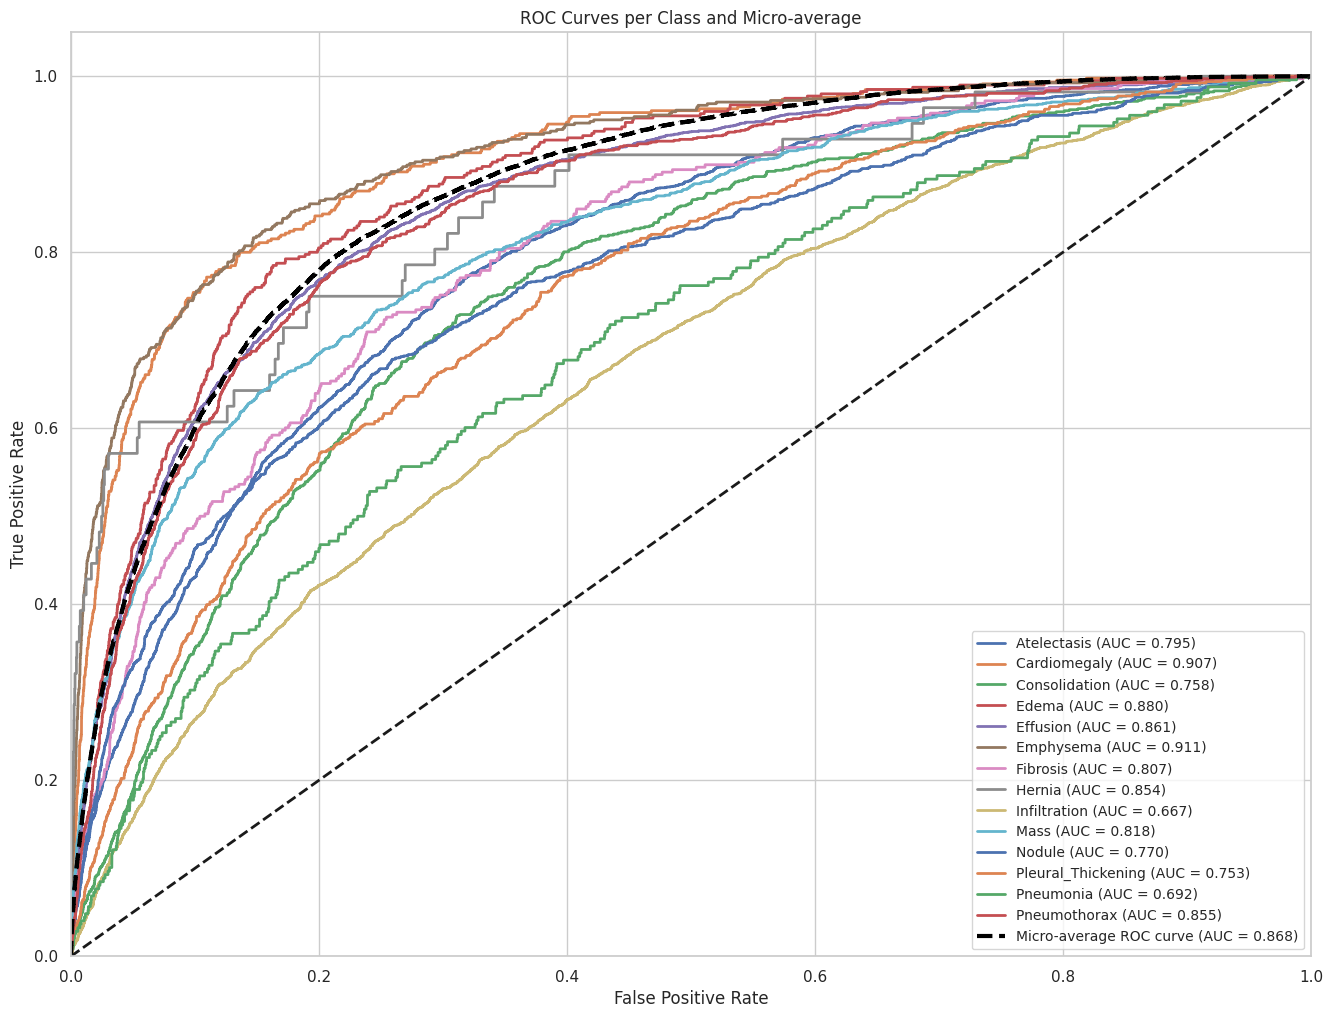

In [ ]:
threshold = history["optimal_thresholds"][5]

results = evaluate_test_set(model_best, test_loader, device, mlb.classes_.tolist(),np.array(threshold))